
# Updated Figure 3 template (2 × 3 layout)

This notebook builds an ASWIFT-style **Figure 3** in a **2 × 3 layout**:

## Top row (OFF response)
1. **Peak (OFF), raw**
2. **Peak (OFF), normalized**
3. **Std. Dev. of normalized response (OFF)**

## Bottom row (ON response)
4. **Peak (ON), raw**
5. **Peak (ON), normalized**
6. **Std. Dev. of normalized response (ON)**

### Included updates
- **No 0-concentration point**
- **Log-scaled x-axis** in every panel
- **3rd column = standard deviation of normalized response**
- Better method separation using:
  - color
  - marker shape
  - line style
  - black marker edges
  - slight log-space x-offsets in overlapping panels
- **Lighter-color error bars / uncertainty bands** drawn for every method in all 6 panels

The notebook includes:
- a synthetic demo dataset so the figure runs immediately
- a helper to convert a `binding_summary.feather`-style table into the plotting format
- export helpers for PNG / PDF / SVG


**Update:** this version uses a **boxed method legend at the bottom**, matching the style used in Figure 2.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from pathlib import Path

# -----------------------------
# ASWIFT-friendly plotting defaults
# -----------------------------
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.size': 9,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.linewidth': 1.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'mathtext.default': 'it',
})


In [9]:

# -----------------------------
# Helpers
# -----------------------------

def lighten_color(color, amount=0.68):
    """Blend a matplotlib color toward white."""
    import matplotlib.colors as mc
    c = np.array(mc.to_rgb(color))
    return tuple((1 - amount) * c + amount * np.ones(3))


def style_axes_logx(ax, concentrations, xlabel=False):
    ax.set_xscale('log')
    ax.set_xlim(concentrations.min() / 1.4, concentrations.max() * 1.4)
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_major_formatter(LogFormatterMathtext())
    ax.tick_params(which='minor', bottom=False)
    if xlabel:
        ax.set_xlabel(r'Concentration, $[M]$')


def add_panel_label(ax, label):
    ax.text(-0.22, 1.06, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')


def save_figure_multi(fig, stem, out_dir='figure_exports'):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f'{stem}.png', transparent=True)
    fig.savefig(out_dir / f'{stem}.pdf', transparent=True)
    fig.savefig(out_dir / f'{stem}.svg', transparent=True)
    print(f'Saved to: {out_dir.resolve()}')


In [10]:
# -----------------------------
# Visual encoding for methods
# Matched to Figure 4 columns 2–3
# -----------------------------

METHODS = {
    'aswift': 'ASWIFT',
    'polynomial': 'Polynomial',
    'multigauss': 'Multi-Gaussian',
    'ewd': 'Extend-Wavelet',
}

METHOD_STYLE = {
    'aswift': {
        'color': '#1f77b4',
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 1.5,
        'markersize': 5.2,
        'offset_decades': 0.000,
        'zorder': 20.0,
    },
    'polynomial': {
        'color': '#ff7f0e',
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 1.5,
        'markersize': 5.2,
        'offset_decades': 0.000,
        'zorder': 3.0,
    },
    'multigauss': {
        'color': '#2ca02c',
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 1.5,
        'markersize': 5.2,
        'offset_decades': 0.000,
        'zorder': 3.0,
    },
    'ewd': {
        'color': '#d62728',
        'marker': 'o',
        'linestyle': '-',
        'linewidth': 1.5,
        'markersize': 5.2,
        'offset_decades': 0.000,
        'zorder': 3.0,
    },
}


def _plot_order_with_aswift_last(methods):
    """Plot non-ASWIFT methods first and ASWIFT last so ASWIFT remains visually on top."""
    order = [method for method in methods if method != 'aswift']
    if 'aswift' in methods:
        order.append('aswift')
    return order


## Helper for your real `binding_summary.feather`

This helper converts a `binding_summary.feather`-style table into the tidy format used below.

### Assumptions
- index values are method keys like:
  - `aswift`
  - `polynomial`
  - `multigauss`
  - `ewd`
- each method row contains array-like entries for:
  - `mean_peak`
  - `std_peak`
- columns include a center/reference amplitude of `1.0`
- values are partitioned as:
  - OFF response: `amp < 1.0`
  - hidden reference response: `amp == 1.0`
  - ON response: `amp > 1.0`
- the `1.0` amplitude point is **not plotted**, but is used as the method-specific denominator for normalizing both OFF and ON responses
- **no 0-concentration point** is included in the plotted concentration grid


In [11]:
def binding_summary_to_tidy(
    peaks_df,
    concentrations=None,
    methods=METHODS,
    reference_amp=1.0,
    amp_tol=1e-8,
):
    """
    Convert a wide binding-summary DataFrame with MultiIndex columns into tidy long form.

    Expected format
    ---------------
    peaks_df.index:
        method names, e.g. aswift, polynomial, multigauss, ewd

    peaks_df.columns:
        MultiIndex with level 0 in {'mean_peak', 'std_peak'}
        and level 1 equal to amp values.

    Assumptions
    -----------
    - OFF responses correspond to amp < reference_amp.
    - ON responses correspond to amp > reference_amp.
    - The center amp == reference_amp response is a calculated reference response.
    - The reference response is NOT plotted.
    - Both OFF and ON responses are normalized by the method-specific
      mean_peak at amp == reference_amp.
    - OFF amp columns are stored in the opposite direction relative to concentration,
      so OFF values are reversed before assigning concentrations / plotting.
    - If `concentrations` is None, amp values are used as x-values.
    """
    if not isinstance(peaks_df.columns, pd.MultiIndex):
        raise ValueError("Expected peaks_df.columns to be a MultiIndex.")

    required_top_levels = {"mean_peak", "std_peak"}
    found_top_levels = set(peaks_df.columns.get_level_values(0))
    missing = required_top_levels - found_top_levels
    if missing:
        raise ValueError(f"Missing required top-level columns: {missing}")

    mean_df = peaks_df["mean_peak"].copy()
    std_df = peaks_df["std_peak"].copy()

    mean_df.columns = pd.Index(mean_df.columns, dtype=float, name="amp")
    std_df.columns = pd.Index(std_df.columns, dtype=float, name="amp")

    if not mean_df.columns.equals(std_df.columns):
        raise ValueError("mean_peak and std_peak amp columns do not match.")

    amp_vals = mean_df.columns.to_numpy(dtype=float)

    ref_mask = np.isclose(amp_vals, reference_amp, rtol=0.0, atol=amp_tol)
    off_mask = amp_vals < (reference_amp - amp_tol)
    on_mask = amp_vals > (reference_amp + amp_tol)

    ref_amps = amp_vals[ref_mask]
    off_amps = amp_vals[off_mask]
    on_amps = amp_vals[on_mask]

    if len(ref_amps) != 1:
        raise ValueError(
            f"Expected exactly one reference amp close to {reference_amp}, "
            f"but found {len(ref_amps)}. Found amps: {amp_vals}"
        )

    if len(off_amps) == 0 or len(on_amps) == 0:
        raise ValueError(
            f"Could not identify both OFF (amp < {reference_amp}) and "
            f"ON (amp > {reference_amp}) groups."
        )

    if len(off_amps) != len(on_amps):
        raise ValueError(
            f"OFF and ON groups have different sizes: "
            f"len(off_amps)={len(off_amps)}, len(on_amps)={len(on_amps)}."
        )

    ref_amp = ref_amps[0]

    if concentrations is not None:
        concentrations = np.asarray(concentrations, dtype=float)
        if len(concentrations) != len(off_amps):
            raise ValueError(
                f"len(concentrations)={len(concentrations)} but expected {len(off_amps)} "
                f"after excluding the hidden amp == {reference_amp} reference point."
            )
        off_conc = concentrations
        on_conc = concentrations
    else:
        off_conc = off_amps[::-1]   # reverse to match OFF ordering
        on_conc = on_amps

    rows = []

    for method in methods:
        if method not in mean_df.index:
            raise KeyError(f"Method '{method}' not found in peaks_df.index")

        # Method-specific calculated response at amp == reference_amp.
        # This is used only for normalization and is intentionally not plotted.
        ref_mean = float(mean_df.loc[method, ref_amp])
        if not np.isfinite(ref_mean) or np.isclose(ref_mean, 0.0):
            raise ValueError(
                f"Method '{method}' has an invalid normalization reference "
                f"at amp == {ref_amp}: {ref_mean}"
            )

        # Raw extraction. The reference amp is excluded from both plotted branches.
        off_means = mean_df.loc[method, off_amps].to_numpy(dtype=float)
        on_means  = mean_df.loc[method, on_amps].to_numpy(dtype=float)
        off_stds  = std_df.loc[method, off_amps].to_numpy(dtype=float)
        on_stds   = std_df.loc[method, on_amps].to_numpy(dtype=float)

        # Reverse OFF branch so it aligns with concentrations from low -> high.
        off_means = off_means[::-1]
        off_stds  = off_stds[::-1]
        off_amp_plot = off_amps[::-1]

        # ON branch already follows the concentration direction.
        on_amp_plot = on_amps

        # Normalize both response directions to the same hidden center response.
        # Use abs(ref_mean) for propagated standard deviations so stds remain positive
        # even if a future dataset stores signed peak responses.
        off_norm = off_means / ref_mean
        on_norm  = on_means / ref_mean

        off_std_norm = off_stds / abs(ref_mean)
        on_std_norm  = on_stds / abs(ref_mean)

        # These are uncertainty estimates for the normalized standard-deviation panels.
        # Set to zero unless you have replicate-level uncertainty on std_peak_norm itself.
        off_std_norm_err = np.zeros_like(off_std_norm)
        on_std_norm_err  = np.zeros_like(on_std_norm)

        for c, a, mp, sp, mn, sn, sne in zip(
            off_conc, off_amp_plot, off_means, off_stds, off_norm, off_std_norm, off_std_norm_err
        ):
            rows.append({
                "method": method,
                "state": "off",
                "concentration": c,
                "amp": a,
                "reference_amp": ref_amp,
                "reference_mean_peak": ref_mean,
                "mean_peak": mp,
                "std_peak": sp,
                "mean_peak_norm": mn,
                "std_peak_norm": sn,
                "std_peak_norm_err": sne,
            })

        for c, a, mp, sp, mn, sn, sne in zip(
            on_conc, on_amp_plot, on_means, on_stds, on_norm, on_std_norm, on_std_norm_err
        ):
            rows.append({
                "method": method,
                "state": "on",
                "concentration": c,
                "amp": a,
                "reference_amp": ref_amp,
                "reference_mean_peak": ref_mean,
                "mean_peak": mp,
                "std_peak": sp,
                "mean_peak_norm": mn,
                "std_peak_norm": sn,
                "std_peak_norm_err": sne,
            })

    return pd.DataFrame(rows)


In [12]:
# -----------------------------
# Plotting functions
# -----------------------------

def plot_series_with_band_and_errorbars(
    ax,
    x,
    y,
    yerr,
    method_key,
    *,
    offset=False,
    other_methods_alpha=0.55,
    aswift_alpha=1.0,
):
    st = METHOD_STYLE[method_key]
    color = st['color']
    lighter = lighten_color(color, amount=0.68)
    alpha = aswift_alpha if method_key == 'aswift' else other_methods_alpha
    zorder = st.get('zorder', 3.0)
    xplot = x * (10 ** st.get('offset_decades', 0.0)) if offset else x

    ax.fill_between(
        xplot, y - 0.70 * yerr, y + 0.70 * yerr,
        color=lighter,
        alpha=0.35 * alpha,
        linewidth=0,
        zorder=zorder - 1,
    )

    ax.errorbar(
        xplot, y, yerr=yerr,
        fmt='none',
        ecolor=lighter,
        alpha=0.65 * alpha,
        elinewidth=1.1,
        capsize=2.3,
        capthick=1.0,
        zorder=zorder,
    )

    ax.plot(
        xplot, y,
        color=color,
        linestyle=st['linestyle'],
        linewidth=st['linewidth'],
        marker=st['marker'],
        markersize=st['markersize'],
        markerfacecolor=color,
        markeredgecolor='black',
        markeredgewidth=0.45,
        alpha=alpha,
        zorder=zorder + 1,
    )


def plot_truth(ax, x, y):
    ax.plot(
        x, y,
        color='black', linestyle=(0, (4, 2)), linewidth=1.0, markersize=4.0,
        markerfacecolor='black', markeredgecolor='black',
        zorder=30.0, label='Ground Truth'
    )


def plot_figure3_2x3(df, concentrations, save_stem=None, truth_reference_peak=1.0):
    fig, axes = plt.subplots(2, 3, figsize=(10.2, 6.6), sharex=False)
    axes = axes.ravel()

    # Model truth for mean response panels only.
    # The normalized truth is referenced to the hidden center amplitude response,
    # whose true peak height is 1.0 in this simulation.
    Kd = 1e-6
    frac_bound = concentrations / (Kd + concentrations)
    truth_off = 1.00 - 0.5 * frac_bound
    truth_on  = 1.00 + 0.5 * frac_bound
    truth_off_norm = truth_off / truth_reference_peak
    truth_on_norm  = truth_on / truth_reference_peak

    panel_specs = [
        ('off', 'mean_peak',      'std_peak',          r'Peak Height, $\mu A$ (OFF)', '(a)', False, truth_off),
        ('off', 'mean_peak_norm', 'std_peak_norm',     r'Normalized Signal',          '(b)', True,  truth_off_norm),
        ('off', 'std_peak_norm',  'std_peak_norm_err', r'Std. Dev.',       '(c)', True,  None),
        ('on',  'mean_peak',      'std_peak',          r'Peak Height, $\mu A$ (ON)',  '(d)', False, truth_on),
        ('on',  'mean_peak_norm', 'std_peak_norm',     r'Normalized Signal',          '(e)', True,  truth_on_norm),
        ('on',  'std_peak_norm',  'std_peak_norm_err', r'Std. Dev.',       '(f)', True,  None),
    ]

    for ax, (state, ycol, errcol, ylabel, label, use_offset, truth) in zip(axes, panel_specs):
        sub = df[df['state'] == state].copy()

        for method_key in _plot_order_with_aswift_last(METHODS):
            d = sub[sub['method'] == method_key].sort_values('concentration')
            x = d['concentration'].to_numpy(dtype=float)
            y = d[ycol].to_numpy(dtype=float)
            yerr = d[errcol].to_numpy(dtype=float)
            plot_series_with_band_and_errorbars(ax, x, y, yerr, method_key, offset=use_offset)

        if truth is not None:
            plot_truth(ax, concentrations, truth)

        style_axes_logx(ax, concentrations, xlabel=label in ['(d)', '(e)', '(f)'])
        ax.set_ylabel(ylabel)
        # add_panel_label(ax, label)

    # y-limits chosen to match the earlier visual style while accommodating the normalized-std column.
    axes[0].set_ylim(0.4, 1.20)
    axes[1].set_ylim(0.4, 1.20)
    axes[2].set_ylim(0.00, 0.07)
    axes[3].set_ylim(0.80, 1.7)
    axes[4].set_ylim(0.80, 1.7)
    axes[5].set_ylim(0.00, 0.1)

    # Boxed legend at the bottom, matching the Figure 2 style.
    # Only the methods are included in the boxed legend.
    method_handles = []
    for method_key, method_label in METHODS.items():
        st = METHOD_STYLE[method_key]
        method_handles.append(
            Line2D([0], [0], color=st['color'], linestyle=st['linestyle'], linewidth=st['linewidth'],
                   marker=st['marker'], markersize=st['markersize'],
                   markerfacecolor=st['color'], markeredgecolor='black', markeredgewidth=0.45,
                   label=method_label)
        )

    ground_truth_handle = Line2D(
        [0], [0],
        color='black',
        linestyle=(0, (4, 2)),
        linewidth=1.0,
        label='Ground Truth',
    )
    legend_handles = method_handles + [ground_truth_handle]

    fig.legend(handles=legend_handles, loc='lower center', ncol=5, frameon=True, fancybox=False,
               edgecolor='black', facecolor='white', bbox_to_anchor=(0.5, 0.02),
               handlelength=2.2, columnspacing=1.8, borderpad=0.8)
    fig.subplots_adjust(top=0.96, bottom=0.20, left=0.08, right=0.98, wspace=0.30, hspace=0.32)

    if save_stem is not None:
        save_figure_multi(fig, save_stem)

    return fig, axes


Saved to: /Users/Max_1/PycharmProjects/echem_peaks/figures/figure_exports


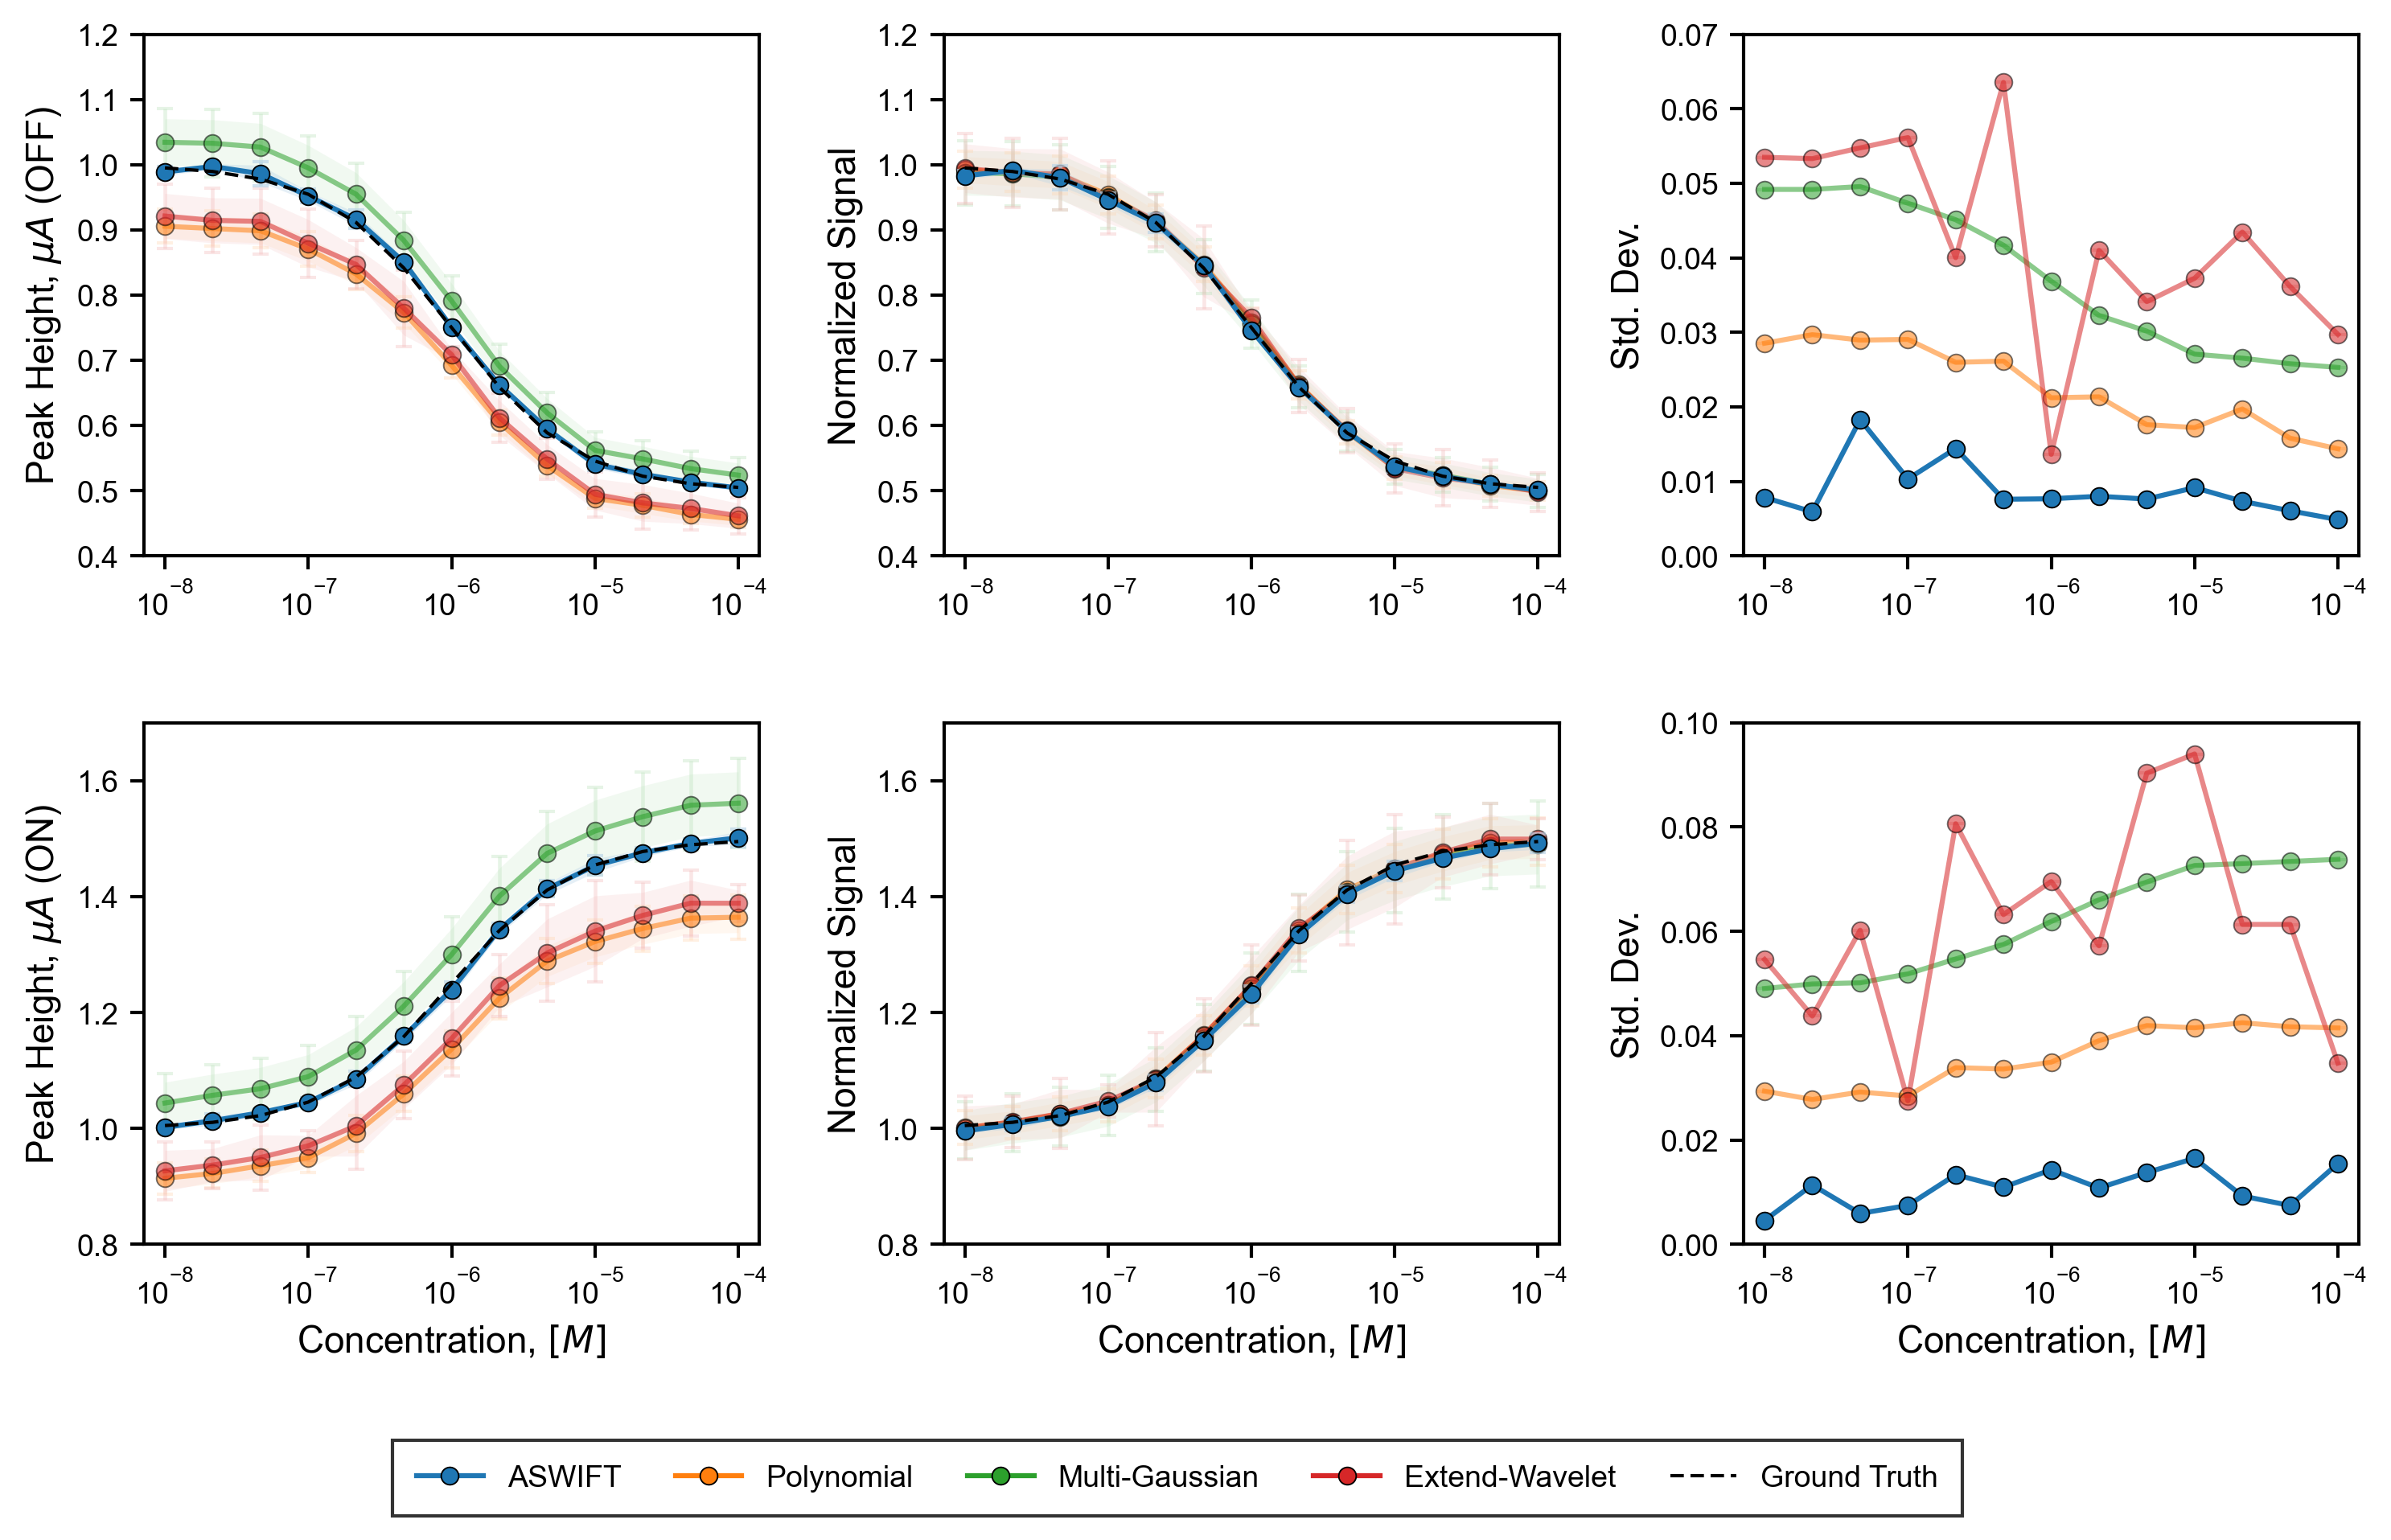

In [13]:
load_path = '../simulation/simulation_data/paper_data/binding_summary.feather'
peaks_df = pd.read_feather(load_path)
concentrations = np.logspace(-8.0, -4.0, 13)  # replace with your real concentration grid

tidy_df = binding_summary_to_tidy(peaks_df, concentrations)
fig, axes = plot_figure3_2x3(tidy_df, concentrations, save_stem='figure3_from_binding_df')
plt.show()